# Project 5 — MOJ Crown Court · **Article 1 visuals**

Every chart and card here is built straight from the Gold tables — no number is typed
by hand. Run the cells top to bottom; each one shows the figure and saves a PNG into
`articles/visuals/`, which is where the article embeds them from.

Style notes (my Medium look): cream background, a bold navy title with a grey subtitle,
a red/blue/orange palette, and a source line with my GitHub on every chart.

## Step 0 — Setup: palette, paths, and two little helpers

`GOLD` is where I read from, `OUT` (`articles/visuals`) is where the PNGs land. The
helpers `frame`, `head` and `foot` keep every chart consistent so I'm not repeating
styling code five times.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from matplotlib.patches import FancyBboxPatch, Rectangle
from pathlib import Path
import pandas as pd

# --- my palette ---
CREAM="#F4F1E9"; INK="#13273A"; RED="#D12E26"; STEEL="#2E6187"
ROYAL="#1D4ED8"; ORANGE="#E08A1E"; MUTED="#8A94A0"; LABEL="#9AA1AC"
GRID="#E4E1D8"; PANEL="#FBFAF7"; PINK="#F7E7E4"; WHITE="#FFFFFF"

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent
GOLD = PROJECT/"data"/"gold"
OUT  = PROJECT/"articles"/"visuals"; OUT.mkdir(parents=True, exist_ok=True)
SRC  = "Source: MOJ Criminal Court Statistics Quarterly, Oct\u2013Dec 2025 (One Crown basis)  |  github.com/YusufIsmailayo"

plt.rcParams.update({
    "font.family":"DejaVu Sans", "figure.facecolor":PANEL, "axes.facecolor":PANEL,
    "axes.edgecolor":MUTED, "axes.linewidth":0.8, "text.color":INK,
    "axes.labelcolor":INK, "xtick.color":INK, "ytick.color":INK, "font.size":11,
})
def frame(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(MUTED); ax.spines["bottom"].set_color(MUTED)
    ax.grid(axis="y", color=GRID, lw=0.9); ax.set_axisbelow(True)
def head(fig, title, sub):
    fig.text(0.075,0.945,title,fontsize=17,fontweight="bold",color=INK,ha="left")
    fig.text(0.075,0.886,sub,fontsize=11.5,color=MUTED,ha="left")
def foot(fig):
    fig.text(0.075,0.03,SRC,fontsize=8.3,color=MUTED,ha="left")
def thousands(x,_): return f"{x:,.0f}"
print("ready · reading from", GOLD.name, "· saving to", OUT.relative_to(PROJECT))

ready · reading from gold · saving to articles/visuals


## Chart 1 — The backlog trajectory

The headline: outstanding cases at the end of each quarter, 2016–2025. I mark the low
point (33,044, end 2018) and the record (80,203, Dec 2025) so the climb is unmissable.

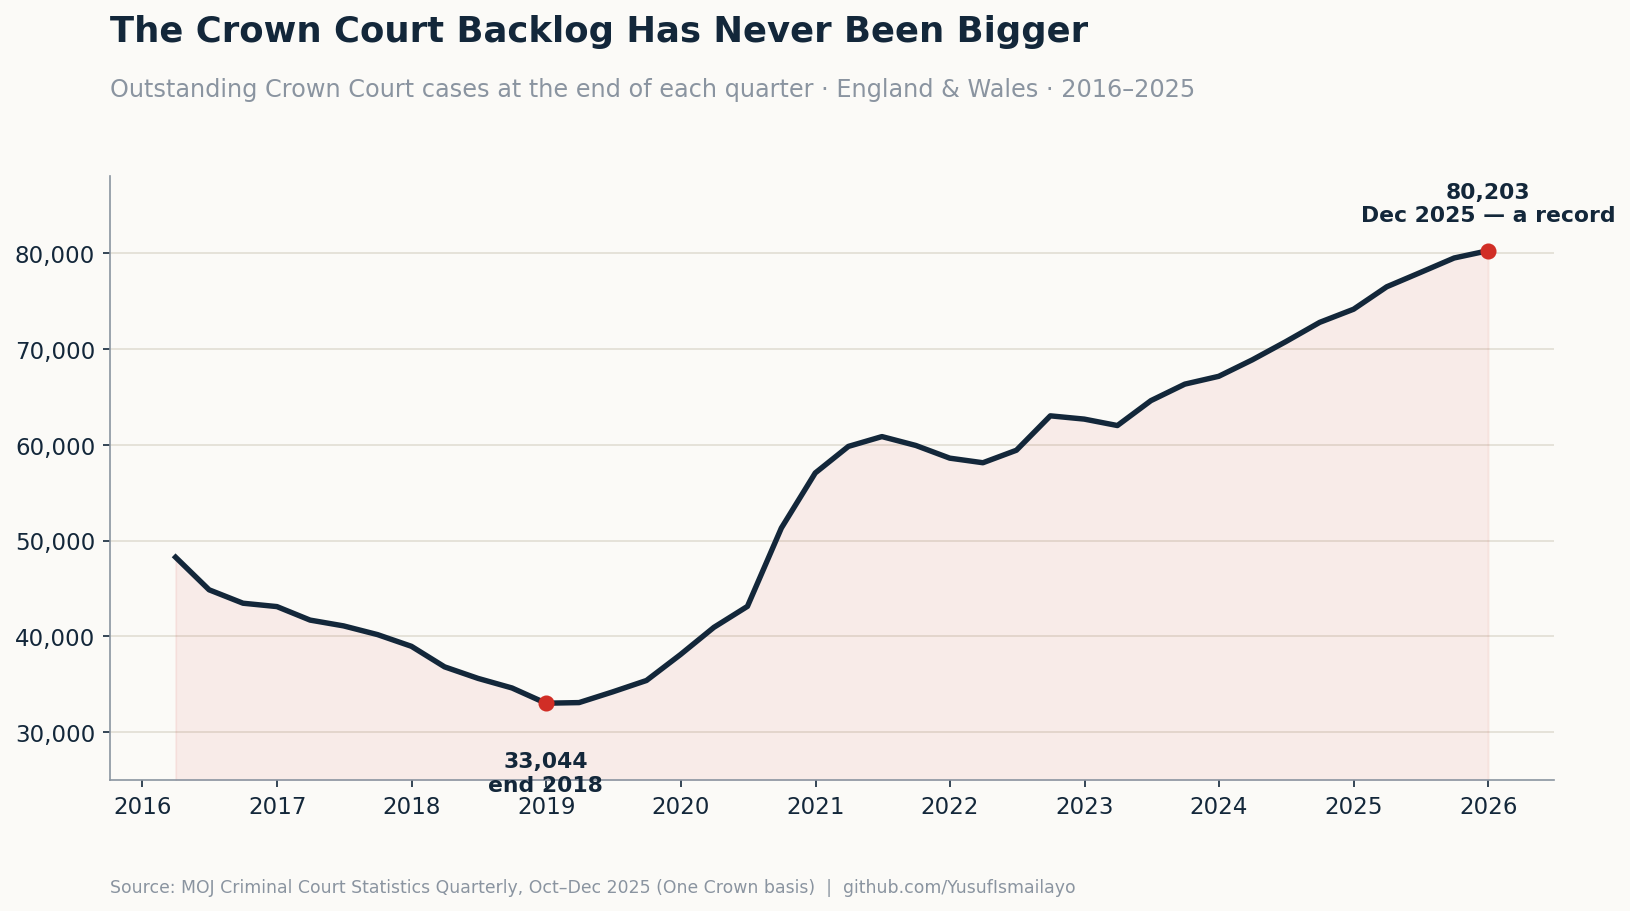

In [3]:
traj = pd.read_parquet(GOLD/"gold_backlog_trajectory.parquet").sort_values("quarter_end")
fig,ax=plt.subplots(figsize=(11,6.2),dpi=150)
fig.subplots_adjust(top=0.80,bottom=0.15,left=0.075,right=0.95)
ax.fill_between(traj.quarter_end,traj.open,color=RED,alpha=0.07)
ax.plot(traj.quarter_end,traj.open,color=INK,lw=2.6)
lo=traj.loc[traj.open.idxmin()]; hi=traj.iloc[-1]
for pt,txt,dy in [(lo,f"{lo.open:,.0f}\nend 2018",-42),(hi,f"{hi.open:,.0f}\nDec 2025 — a record",14)]:
    ax.scatter([pt.quarter_end],[pt.open],color=RED,zorder=5,s=45)
    ax.annotate(txt,(pt.quarter_end,pt.open),xytext=(0,dy),textcoords="offset points",
                ha="center",fontsize=10.5,fontweight="bold",color=INK)
ax.yaxis.set_major_formatter(FuncFormatter(thousands)); ax.set_ylim(25000,88000)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
frame(ax); head(fig,"The Crown Court Backlog Has Never Been Bigger",
    "Outstanding Crown Court cases at the end of each quarter \u00b7 England & Wales \u00b7 2016\u20132025"); foot(fig)
fig.savefig(OUT/"01_backlog_trajectory.png"); plt.show()

## Chart 2 — More in than out (the engine)

Quarterly receipts vs disposals. Where the red (received) line sits above the blue
(disposed) line, the backlog grows — I shade that gap. This is the paradox made visible:
disposals are rising, but receipts are rising faster.

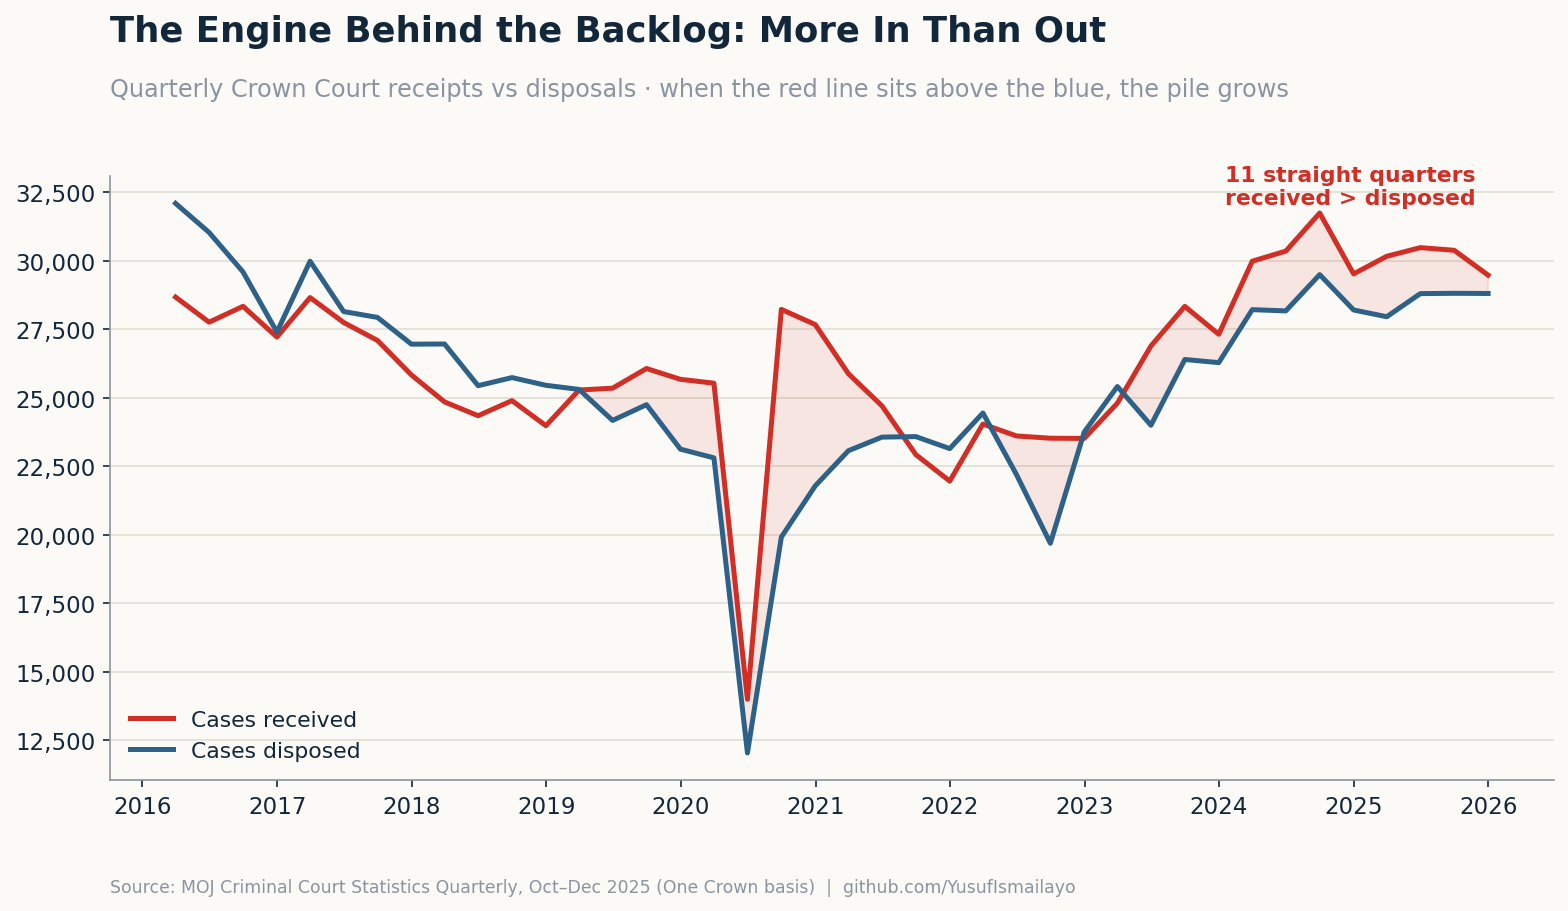

In [5]:
fig,ax=plt.subplots(figsize=(11,6.2),dpi=150)
fig.subplots_adjust(top=0.80,bottom=0.15,left=0.075,right=0.95)
ax.plot(traj.quarter_end,traj.receipts,color=RED,lw=2.4,label="Cases received")
ax.plot(traj.quarter_end,traj.disposals,color=STEEL,lw=2.4,label="Cases disposed")
ax.fill_between(traj.quarter_end,traj.disposals,traj.receipts,
                where=(traj.receipts>=traj.disposals),color=RED,alpha=0.10,interpolate=True)
ax.yaxis.set_major_formatter(FuncFormatter(thousands))
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(frameon=False,loc="lower left",fontsize=10.5)
ax.annotate("11 straight quarters\nreceived > disposed",(traj.iloc[-1].quarter_end,traj.iloc[-1].receipts),
            xytext=(-6,34),textcoords="offset points",ha="right",fontsize=10.5,fontweight="bold",color=RED)
frame(ax); head(fig,"The Engine Behind the Backlog: More In Than Out",
    "Quarterly Crown Court receipts vs disposals \u00b7 when the red line sits above the blue, the pile grows"); foot(fig)
fig.savefig(OUT/"02_more_in_than_out.png"); plt.show()

## Chart 3 — It's older, not just bigger

The share of open cases that have been waiting a year or more — from 6.5% at the end of
2019 to 27.7% at the end of 2025. A big backlog that also ages is a different problem
from a big backlog that moves.

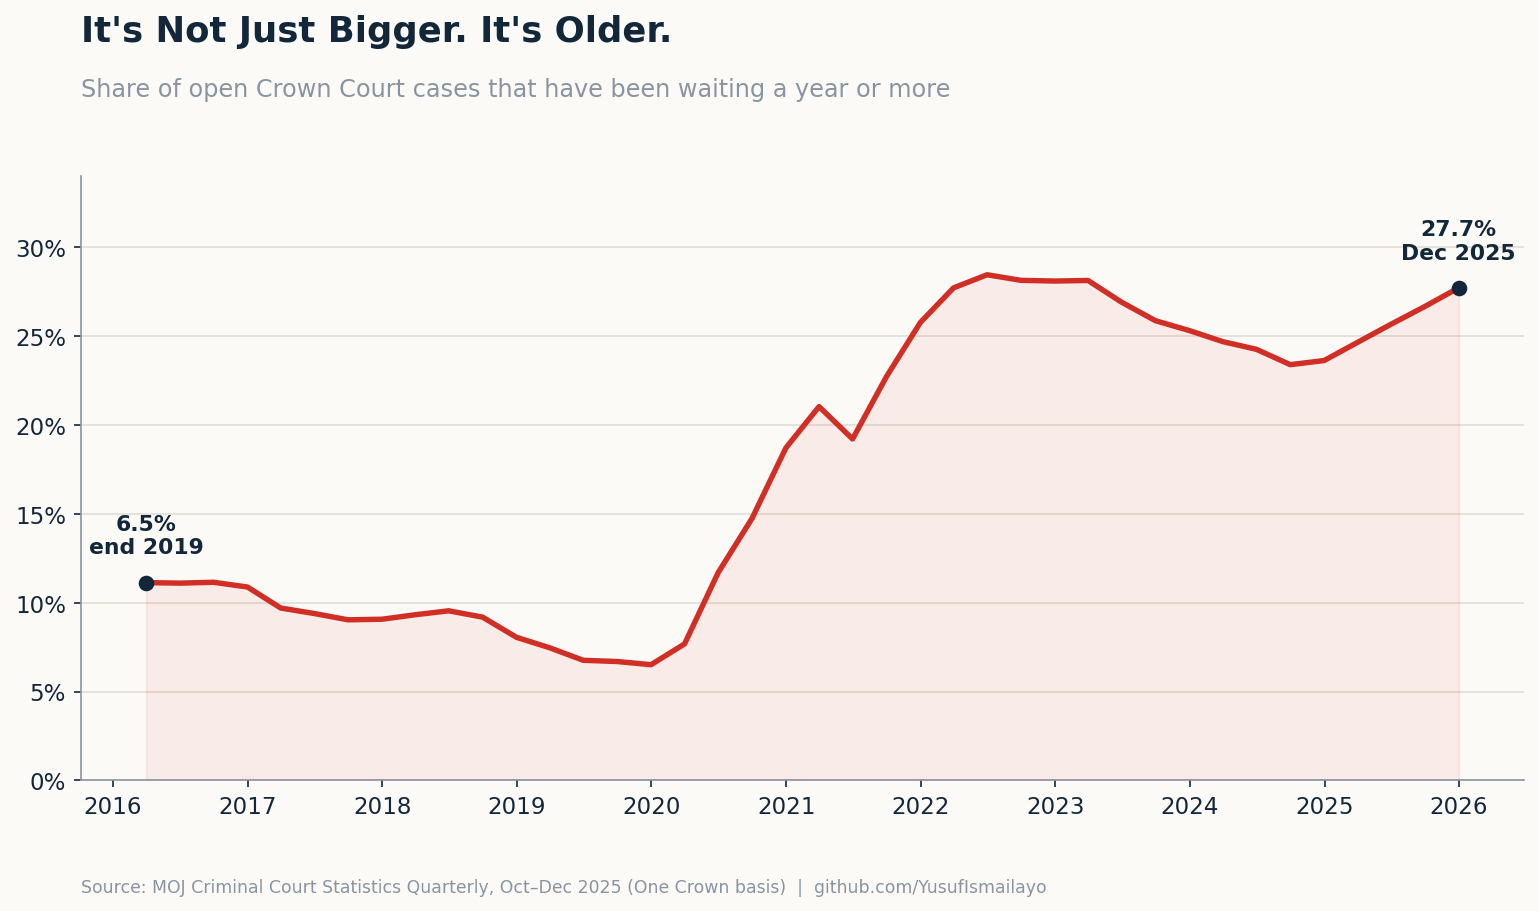

In [7]:
summ=pd.read_parquet(GOLD/"gold_caseload_age_summary.parquet").sort_values("quarter_end")
fig,ax=plt.subplots(figsize=(11,6.2),dpi=150)
fig.subplots_adjust(top=0.80,bottom=0.15,left=0.075,right=0.95)
ax.fill_between(summ.quarter_end,summ.share_1yr_plus*100,color=RED,alpha=0.07)
ax.plot(summ.quarter_end,summ.share_1yr_plus*100,color=RED,lw=2.6)
for q,lbl in [(summ.iloc[0],"6.5%\nend 2019"),(summ.iloc[-1],"27.7%\nDec 2025")]:
    ax.scatter([q.quarter_end],[q.share_1yr_plus*100],color=INK,zorder=5,s=42)
    ax.annotate(lbl,(q.quarter_end,q.share_1yr_plus*100),xytext=(0,14),textcoords="offset points",
                ha="center",fontsize=10.5,fontweight="bold",color=INK)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,_:f"{x:.0f}%")); ax.set_ylim(0,34)
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
frame(ax); head(fig,"It's Not Just Bigger. It's Older.",
    "Share of open Crown Court cases that have been waiting a year or more"); foot(fig)
fig.savefig(OUT/"03_ageing_share.png"); plt.show()

## Chart 4 — The oldest cases are the most serious

Open cases waiting a year or more, broken down by offence (Dec 2025). Violence against
the person and sexual offences are highlighted red — together they are 52.8% of the
oldest caseload.

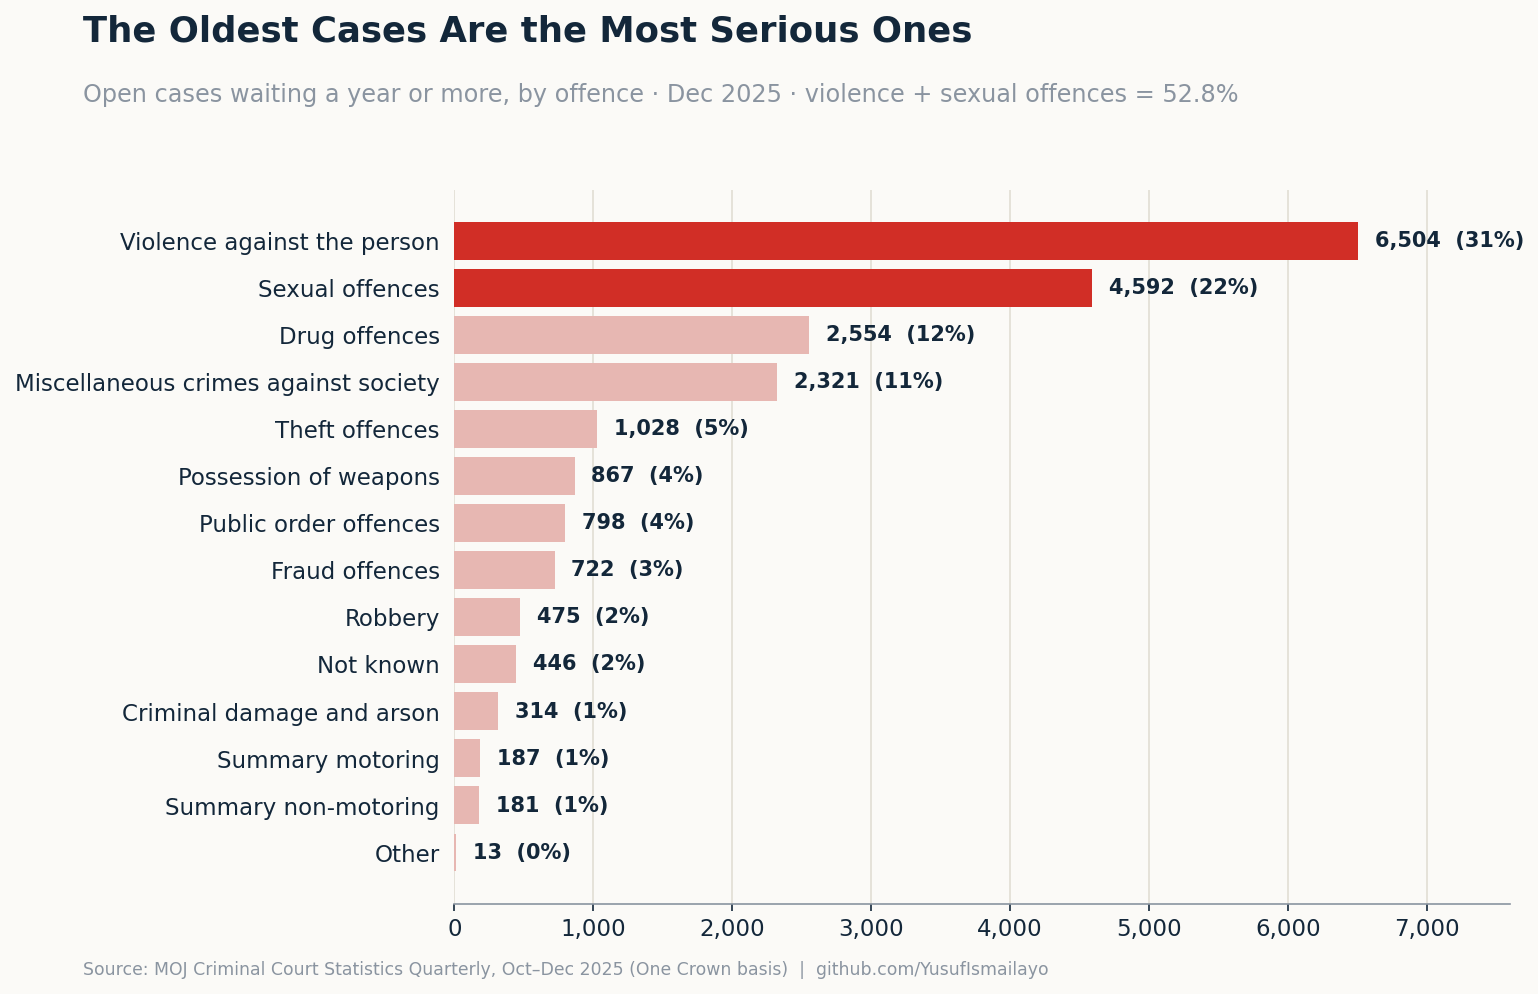

In [9]:
byof=pd.read_parquet(GOLD/"gold_oldest_by_offence.parquet")
L=byof.quarter_end.max(); d=byof[byof.quarter_end==L].sort_values("open_1yr_plus")
serious={"Violence against the person","Sexual offences"}
colors=[RED if o in serious else "#E7B7B2" for o in d.offence]
fig,ax=plt.subplots(figsize=(11,6.8),dpi=150)
fig.subplots_adjust(top=0.80,bottom=0.10,left=0.30,right=0.94)
bars=ax.barh(d.offence,d.open_1yr_plus,color=colors)
for b,v,s in zip(bars,d.open_1yr_plus,d.share_of_quarter):
    ax.text(v+120,b.get_y()+b.get_height()/2,f"{v:,.0f}  ({s:.0%})",va="center",fontsize=10,fontweight="bold",color=INK)
ax.xaxis.set_major_formatter(FuncFormatter(thousands)); ax.set_xlim(0,7600)
for s in ["top","right","left"]: ax.spines[s].set_visible(False)
ax.grid(axis="x",color=GRID,lw=0.9); ax.set_axisbelow(True); ax.tick_params(left=False)
head(fig,"The Oldest Cases Are the Most Serious Ones",
    "Open cases waiting a year or more, by offence \u00b7 Dec 2025 \u00b7 violence + sexual offences = 52.8%"); foot(fig)
fig.savefig(OUT/"04_oldest_by_offence.png"); plt.show()

## Cover + social cards

Same design as my Medium cards: kicker, red rule, a Playfair-style serif title with the
red italic line, three stat cards, the pull-quote, and my footer. Here they're drawn
with DejaVu Serif (the fonts installed locally); for a pixel-perfect Playfair export use
`articles/visuals/cover_card_template.html` in a browser. `build(square=False)` makes the
landscape (Medium/LinkedIn/X) card; `build(square=True)` makes the Instagram square.

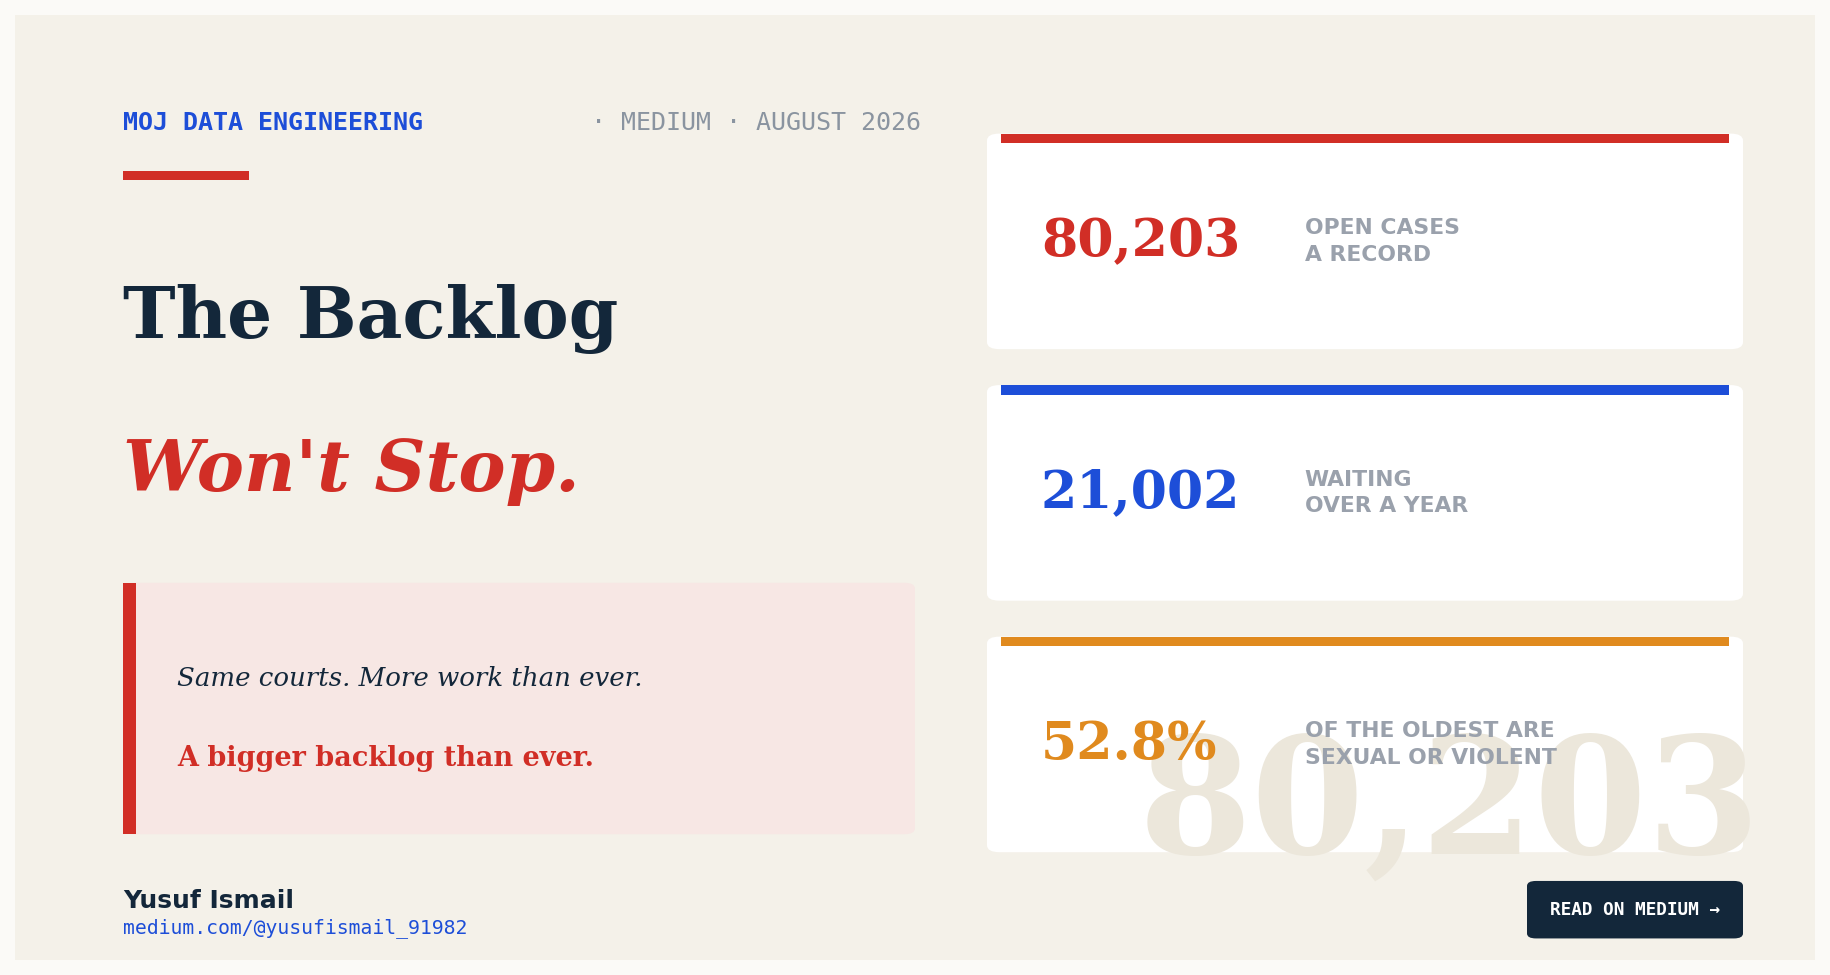

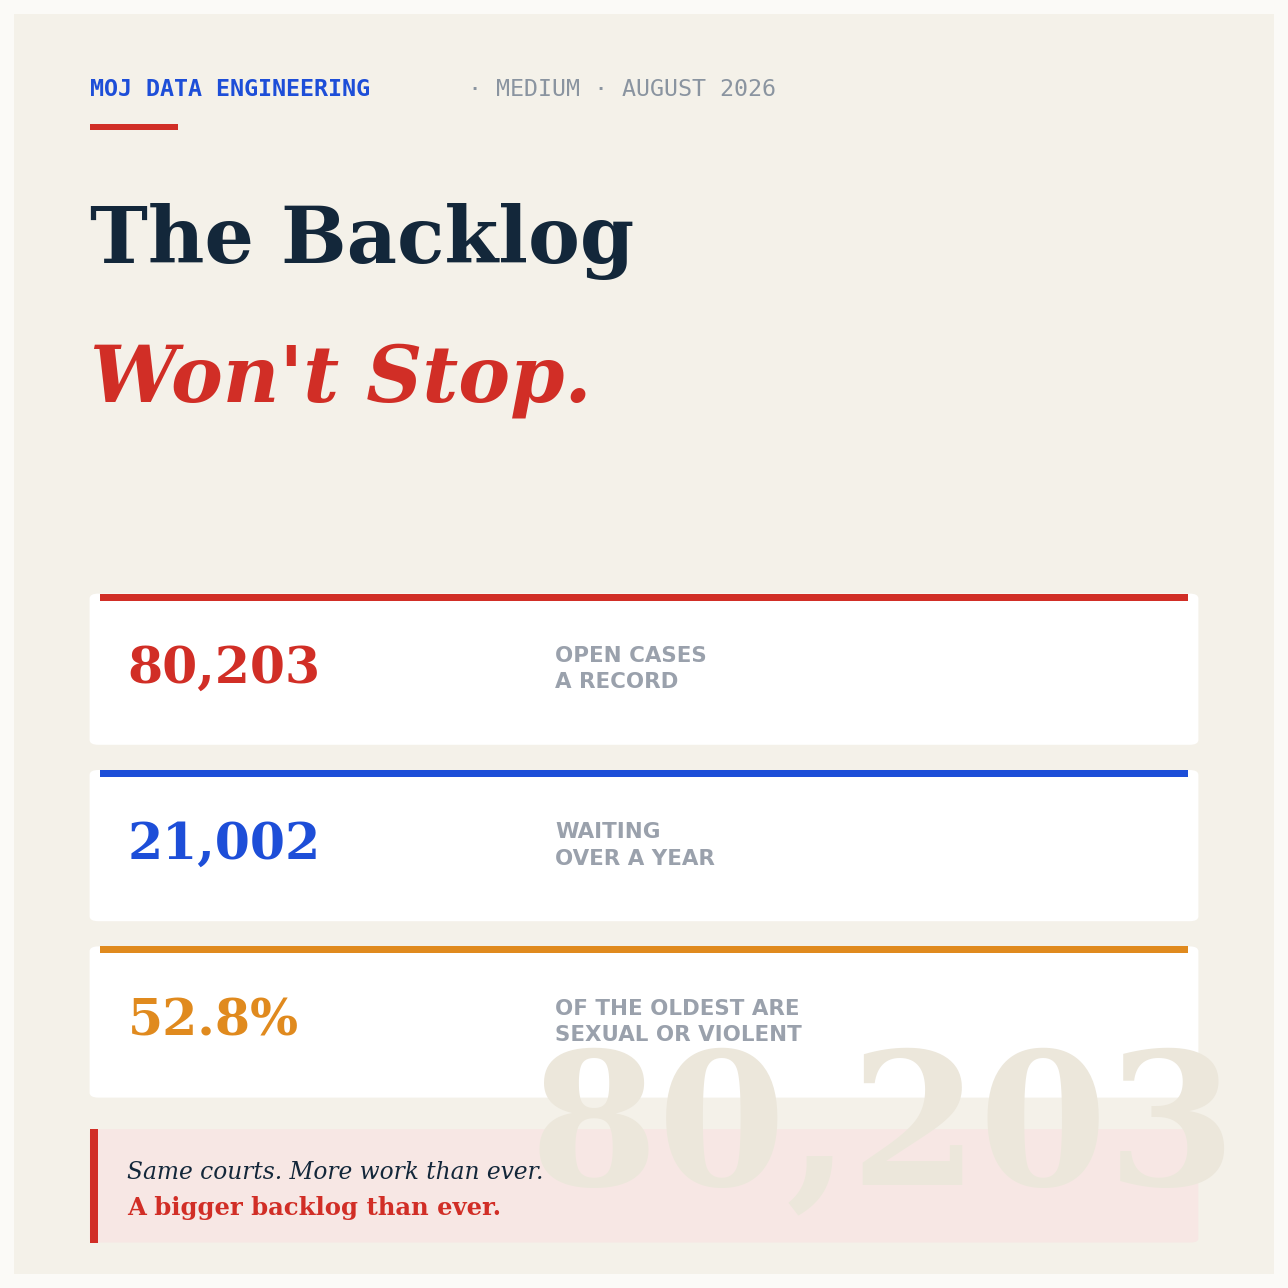

cards saved.


In [11]:
SERIF="DejaVu Serif"; MONO="DejaVu Sans Mono"; SANS="DejaVu Sans"
def rrect(ax,x,y,w,h,fc,rad=0.6,z=1):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle=f"round,pad=0,rounding_size={rad}",
                 fc=fc,ec="none",lw=0,zorder=z,mutation_aspect=0.55))
def build(square=False):
    if square: fig=plt.figure(figsize=(9,9),dpi=140); W,H=100,100
    else:      fig=plt.figure(figsize=(12,6.3),dpi=150); W,H=100,52.6
    ax=fig.add_axes([0,0,1,1]); ax.axis("off"); ax.set_xlim(0,W); ax.set_ylim(0,H)
    ax.add_patch(Rectangle((0,0),W,H,fc=CREAM,zorder=0)); top=H-6
    ax.text(W-3,4,"80,203",fontsize=95 if square else 78,fontweight="bold",color="#ECE7DB",ha="right",va="bottom",family=SERIF)
    ax.text(6,top,"MOJ DATA ENGINEERING",fontsize=12,color=ROYAL,family=MONO,fontweight="bold",va="center")
    ax.text(6+(30 if square else 26),top,"\u00b7 MEDIUM \u00b7 AUGUST 2026",fontsize=12,color=MUTED,family=MONO,va="center")
    ax.add_patch(Rectangle((6,top-3.2),7,0.5,fc=RED,zorder=2))
    ty=top-9
    ax.text(6,ty,"The Backlog",fontsize=40 if square else 34,color=INK,family=SERIF,fontweight="bold",va="top")
    ax.text(6,ty-(11 if square else 8.5),"Won't Stop.",fontsize=40 if square else 34,color=RED,family=SERIF,fontweight="bold",style="italic",va="top")
    if square: cx,cw,ys,ch=6,88,[42,28,14],12
    else:      cx,cw,ys,ch=54,42,[34,20,6],12
    for (num,col,l1,l2),cy in zip([("80,203",RED,"OPEN CASES","A RECORD"),
        ("21,002",ROYAL,"WAITING","OVER A YEAR"),("52.8%",ORANGE,"OF THE OLDEST ARE","SEXUAL OR VIOLENT")],ys):
        rrect(ax,cx,cy,cw,ch,WHITE,rad=0.7,z=2)
        ax.add_patch(Rectangle((cx+0.8,cy+ch-0.55),cw-1.6,0.55,fc=col,zorder=3))
        ax.text(cx+3,cy+ch/2,num,fontsize=26 if square else 25,color=col,family=SERIF,fontweight="bold",va="center",zorder=4)
        ax.text(cx+cw*0.42,cy+ch/2,f"{l1}\n{l2}",fontsize=11 if square else 10.5,color=LABEL,family=SANS,fontweight="bold",va="center",linespacing=1.4,zorder=4)
    if square: qx,qy,qw,qh=6,2.5,88,9
    else:      qx,qy,qw,qh=6,7,44,14
    rrect(ax,qx,qy,qw,qh,PINK,rad=0.6,z=1); ax.add_patch(Rectangle((qx,qy),0.7,qh,fc=RED,zorder=3))
    ax.text(qx+3,qy+qh*0.62,"Same courts. More work than ever.",fontsize=12 if square else 12.5,color=INK,style="italic",family=SERIF,va="center")
    ax.text(qx+3,qy+qh*0.30,"A bigger backlog than ever.",fontsize=12.5 if square else 13,color=RED,fontweight="bold",family=SERIF,va="center")
    if not square:
        ax.text(6,2.6,"Yusuf Ismail",fontsize=12,color=INK,fontweight="bold",family=SANS,va="bottom")
        ax.text(6,1.2,"medium.com/@yusufismail_91982",fontsize=9.5,color=ROYAL,family=MONO,va="bottom")
        rrect(ax,84,1.2,12,3.2,INK,rad=0.5,z=3)
        ax.text(90,2.8,"READ ON MEDIUM \u2192",fontsize=8.5,color=WHITE,fontweight="bold",family=MONO,ha="center",va="center",zorder=4)
    tag="social_square" if square else "cover_landscape"
    fig.savefig(OUT/f"05_{tag}.png",facecolor=CREAM); return fig
build(False); plt.show(); build(True); plt.show()
print("cards saved.")

---
### Visuals complete
Six PNGs are in `articles/visuals/` (four charts + the landscape and square cards), all
rebuilt from the Gold tables. The article embeds them by relative path. For a
pixel-perfect Playfair export of the cards, open `cover_card_template.html` in a browser.